# nohp model output inspection (lat/lon grid)

Loads raw predictions and targets from trained nohp (lat/lon grid) climate models.
Companion to `check_outputs_from_models.ipynb` (HEALPix models).

## Cross-notebook comparison
Set `TARGET_YEAR` and `TARGET_MONTH` to the same values in both notebooks to inspect
the identical timestep from both model families side by side.

Array convention: nohp spatial axes are `(lat_axis, lon_axis)` — shape `(C, n_lat, n_lon)`.
Visualization cells apply `.T` to facilitate longitudinal rolling, then `.T` again in `imshow`.

In [14]:
import sys
sys.path.insert(0, "/home/x_tagty/equivariant-posteriors")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from experiments.climate.notebooks.sample_predictions_nohp import (
    get_sample_predictions_nohp,
    get_predictions_for_timestamp_nohp,
)
from experiments.climate.evaluation.evaluate_climate_nohp import load_create_config
from experiments.climate.evaluation.timestamp_utils import (
    sample_id_to_timestamp,
    format_timestamp,
    MONTH_NAMES,
)

In [ ]:

import glob, os, io, contextlib, duckdb

from lib.paths import get_checkpoint_path
from experiments.climate.data.climateset_data_no_hp import ClimatesetData


def _query_all_steps(checkpoint_dir, metric_name):
    """Return list of (step, mean_float) from all duck_*.db files in checkpoint_dir."""
    db_files = sorted(glob.glob(os.path.join(str(checkpoint_dir), "duck_*.db")))
    rows = []
    for db_path in db_files:
        try:
            con = duckdb.connect(db_path, read_only=True)
            rows.extend(con.execute(
                "SELECT step, mean_float FROM checkpoint_sample_metric "
                "WHERE name = ? AND mean_float IS NOT NULL",
                [metric_name],
            ).fetchall())
            con.close()
        except Exception:
            pass
    return rows


def get_best_epoch_nohp(curried, seed=0, metric_name="rmse_latw_overall"):
    """Return (best_epoch, best_val) considering only epochs whose checkpoint files exist."""
    train_run = curried(ensemble_id=seed)
    checkpoint_dir = get_checkpoint_path(train_run.train_config)
    rows = _query_all_steps(checkpoint_dir, metric_name)
    if not rows:
        return None, None
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        train_ds = ClimatesetData(train_run.train_config.train_data_config)
    n_train = len(train_ds)
    best_epoch, best_val = None, float("inf")
    for step, val in rows:
        epoch = round(step / n_train)
        if (checkpoint_dir / f"model_epoch_{epoch:04d}").is_file() and val < best_val:
            best_val, best_epoch = val, epoch
    return best_epoch, best_val


def sample_rmse(r, var_name):
    """Simple spatial RMSE for a single-timestep result dict (prediction/target shape (C, H, W))."""
    vi   = r["var_names"].index(var_name)
    pred = np.asarray(r["prediction"][vi]).ravel()
    tgt  = np.asarray(r["target"][vi]).ravel()
    return float(np.sqrt(np.mean((pred - tgt) ** 2)))


## Config — edit these

Set `TARGET_YEAR` / `TARGET_MONTH` to the same values used in the HP notebook
(`check_outputs_from_models.ipynb`) to compare the exact same timestep.

In [16]:
# Path to a nohp persisted config (CNN-LSTM, UNet, or ClimaX)
CONFIG = "/home/x_tagty/equivariant-posteriors/experiments/climate/persisted_configs/final_climateset_baseline_runs/train_climax_nohp_multiseed_latfix.py"

# Climate model indices to compare (0-14)
# 0=AWI-CM-1-1-MR  2=CAS-ESM2-0  7=GFDL-ESM4  12=NorESM2-LM
CLIMATE_MODEL_IDXS = [2, 7, 12]

EPOCH = None  # None → auto-select best epoch from DuckDB; set an int to pin manually
SEED  = 0

# ---- Cross-notebook timestamp anchor ----
# Set these to the same values in check_outputs_from_models.ipynb
# to guarantee you are looking at the identical timestep.
TARGET_YEAR  = 2040
TARGET_MONTH = 4    # 1=Jan ... 12=Dec

# Output variable for map panels
VAR_NAME = "pr"    # or "tas"

# For the multi-batch exploratory cells below
N_BATCHES = 3   # 3 x 4 = 12 sequences x seq_len months each

## 1 · Exact timestep comparison — same sample as HP notebook

In [17]:
base_create_config = load_create_config(CONFIG)

ts_results = {}
for idx in CLIMATE_MODEL_IDXS:
    def make_curried(climate_idx):
        return lambda ensemble_id, **kw: base_create_config(
            ensemble_id=ensemble_id,
            climate_model_idx=climate_idx,
            **kw,
        )
    curried = make_curried(idx)
    _ep = EPOCH
    if _ep is None:
        _ep, _best_val = get_best_epoch_nohp(curried, seed=SEED)
        if _ep is None:
            raise RuntimeError(
                f"No DuckDB metrics found for climate_model_idx={idx}. Set EPOCH manually."
            )
        print(f"  [idx={idx}] best epoch from DuckDB: {_ep}  (val RMSE={_best_val:.4e})")
    print(f"Loading idx={idx}, epoch={_ep}, target={MONTH_NAMES[TARGET_MONTH-1]} {TARGET_YEAR} ...")
    r = get_predictions_for_timestamp_nohp(
        curried, _ep, year=TARGET_YEAR, month=TARGET_MONTH, variant_idx=SEED
    )
    r["used_epoch"] = _ep
    r["sample_rmse"] = sample_rmse(r, VAR_NAME)
    ts_results[idx] = r
    print(f"  -> {r['model_name']}  timestamp: {r['timestamp_label']}  "
          f"prediction shape: {r['prediction'].shape}  RMSE({VAR_NAME})={r['sample_rmse']:.4e}")

print("\nAll loaded. Variables:", ts_results[CLIMATE_MODEL_IDXS[0]]["var_names"])

climate_model=CAS-ESM2-0, ensemble=r3i1p1f1, seed=0
Using 16 workers [SLURM_CPUS_ON_NODE]
  [idx=2] best epoch from DuckDB: 30  (val RMSE=2.8209e-01)
Loading idx=2, epoch=30, target=Apr 2040 ...
climate_model=CAS-ESM2-0, ensemble=r3i1p1f1, seed=0
Using 16 workers [SLURM_CPUS_ON_NODE]
Loading cached INPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_grid_BC_CH4_SO2_CO2_ssp245_2015-2100_nohistoric_anthro-fires
  Loaded INPUT from cache: shape=(1032, 4, 96, 144)
Loading cached OUTPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/outputs_CAS-ESM2-0_r3i1p1f1_grid_tas_pr_ssp245_2015-2100_nohistoric_250_km
  Loaded OUTPUT from cache: shape=(1032, 2, 96, 144)
Using 86 start indices for split='test' (seq_len=12)
  split='test': stats must be provided explicitly.
  Call set_normalization_stats() before using this dataset.
Loaded input stats from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_grid_BC_CH4_SO2_CO2_ssp126_ssp370_ssp585_2015-2100_nohistoric_ant

RuntimeError: Could not load checkpoint for epoch=30, variant=0.

### Single model — True / Predicted / Error

Spatial axes: `prediction` shape is `(C, n_lat, n_lon)`.  
Visualization applies `.T` → roll longitude by half → `.T` in `imshow` for standard map orientation.

In [ ]:
def plot_nohp_true_pred_error(r, var_name, fig_title=None):
    var_idx  = r["var_names"].index(var_name)
    # Transpose so that axis-0 = lon, axis-1 = lat (for rolling), then .T into imshow
    true_map = r["target"][var_idx].T
    pred_map = r["prediction"][var_idx].T
    err_map  = r["error"][var_idx].T

    # Roll longitude by half to get standard orientation (Americas left, Europe right)
    n_lon = true_map.shape[0]
    true_map = np.roll(true_map, n_lon // 2, axis=0)
    pred_map = np.roll(pred_map, n_lon // 2, axis=0)
    err_map  = np.roll(err_map,  n_lon // 2, axis=0)

    lats = r["lats"]  # (n_lat,) or None
    unit = "" #"K" if var_name == "tas" else "kg/m2/s"
    vmin, vmax = true_map.min(), true_map.max()

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    if fig_title:
        fig.suptitle(fig_title, fontsize=10)

    for ax, arr, title, cmap, v0, v1 in [
        (axes[0], true_map, f"True {var_name} {unit}",      "RdBu_r", vmin, vmax),
        (axes[1], pred_map, f"Predicted {var_name} {unit}", "RdBu_r", vmin, vmax),
        (axes[2], err_map,  f"Abs Error {var_name} {unit}", "YlOrRd", 0, None),
    ]:
        im = ax.imshow(arr.T, origin="lower", cmap=cmap,
                       vmin=v0, vmax=v1, aspect="auto")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.04)

    plt.tight_layout()
    plt.show()


idx0 = CLIMATE_MODEL_IDXS[0]
r0   = ts_results[idx0]
_ep0 = r0.get("used_epoch", EPOCH)
_rm0 = r0.get("sample_rmse")
_rm_s = f"  RMSE={_rm0:.3e}" if _rm0 is not None else ""
plot_nohp_true_pred_error(
    r0, VAR_NAME,
    fig_title=f"{r0['model_name']}  {r0['timestamp_label']}  seed={SEED}  ep={_ep0}{_rm_s}"
)

### Multi-model comparison at the same timestep

In [ ]:
n_models = len(CLIMATE_MODEL_IDXS)
fig, axes = plt.subplots(n_models, 3, figsize=(22, 5.5 * n_models))
fig.suptitle(
    f"{VAR_NAME}  —  {format_timestamp('ssp245', TARGET_YEAR, TARGET_MONTH)}  seed={SEED}",
    fontsize=14
)

for row, idx in enumerate(CLIMATE_MODEL_IDXS):
    r = ts_results[idx]
    var_idx  = r["var_names"].index(VAR_NAME)
    true_map = r["target"][var_idx].T
    pred_map = r["prediction"][var_idx].T
    err_map  = r["error"][var_idx].T

    # Roll longitude by half to get standard orientation (Americas left, Europe right)
    n_lon = true_map.shape[0]
    true_map = np.roll(true_map, n_lon // 2, axis=0)
    pred_map = np.roll(pred_map, n_lon // 2, axis=0)
    err_map  = np.roll(err_map,  n_lon // 2, axis=0)

    vmin, vmax = true_map.min(), true_map.max()
    name = r["model_name"]
    _ep  = r.get("used_epoch", EPOCH)
    _rm  = r.get("sample_rmse")
    _rm_s = f"  RMSE={_rm:.3e}" if _rm is not None else ""

    row_axes = axes[row] if n_models > 1 else axes
    for ax, arr, title, cmap, v0, v1 in [
        (row_axes[0], true_map, f"{name}  ep={_ep}{_rm_s}\nTrue",  "RdBu_r", vmin, vmax),
        (row_axes[1], pred_map, f"{name}\nPredicted",               "RdBu_r", vmin, vmax),
        (row_axes[2], err_map,  f"{name}\nAbs Error",               "YlOrRd", 0, None),
    ]:
        im = ax.imshow(arr.T, origin="lower", cmap=cmap, vmin=v0, vmax=v1, aspect="auto")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.04)

plt.tight_layout()
plt.show()

---
## 2 · Exploratory multi-batch section

Load `N_BATCHES` worth of sequences and inspect the error distribution over time.

In [ ]:
results = {}
for idx in CLIMATE_MODEL_IDXS:
    def make_curried(climate_idx):
        return lambda ensemble_id, **kw: base_create_config(
            ensemble_id=ensemble_id,
            climate_model_idx=climate_idx,
            **kw,
        )
    curried = make_curried(idx)
    # Reuse the epoch resolved in section 1 (or fall back to EPOCH)
    _ep = ts_results[idx].get("used_epoch", EPOCH) if idx in ts_results else EPOCH
    print(f"Loading idx={idx}, epoch={_ep}, {N_BATCHES} batches ...")
    results[idx] = get_sample_predictions_nohp(
        curried, _ep, variant_idx=SEED, n_batches=N_BATCHES
    )
    r = results[idx]
    seq_len = r["seq_len"]
    # Print what timesteps were loaded (first and last sample_id)
    first_sid = r["sample_ids"][0]
    last_sid  = r["sample_ids"][-1]
    sc0, y0, m0 = sample_id_to_timestamp(first_sid,             r["test_data_config"])
    sc1, y1, m1 = sample_id_to_timestamp(last_sid + seq_len - 1, r["test_data_config"])
    print(f"  -> {r['model_name']}  predictions shape: {r['predictions'].shape}")
    print(f"     covers {format_timestamp(sc0, y0, m0)} → {format_timestamp(sc1, y1, m1)}")

print("Done.")

### Error distributions

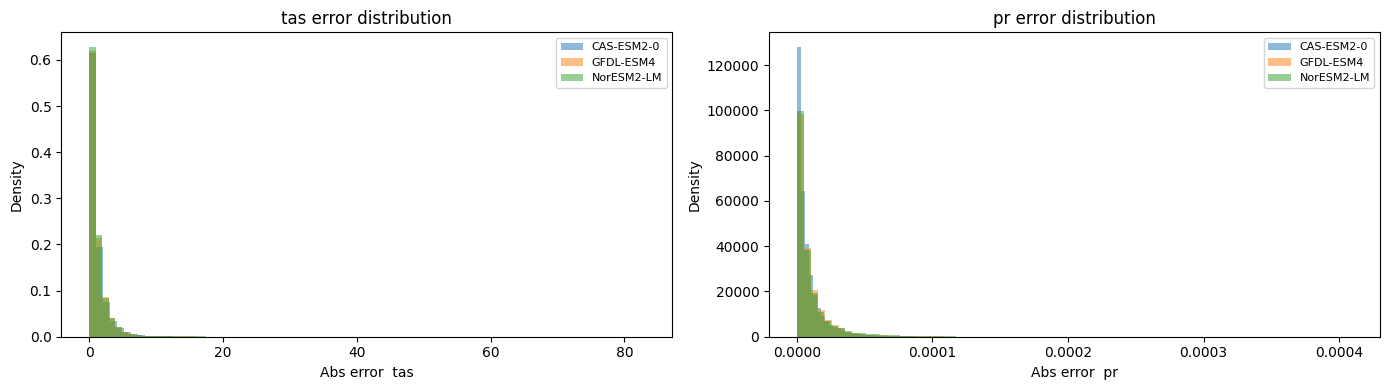

In [16]:
var_names = results[CLIMATE_MODEL_IDXS[0]]["var_names"]
seq_len   = results[CLIMATE_MODEL_IDXS[0]]["seq_len"]

fig, axes = plt.subplots(1, len(var_names), figsize=(7 * len(var_names), 4))
if not hasattr(axes, "__len__"):
    axes = [axes]

for var_idx, var_name in enumerate(var_names):
    ax = axes[var_idx]
    for idx in CLIMATE_MODEL_IDXS:
        r = results[idx]
        errs = r["errors"]
        # errs shape: (N, T, C, H, W) or (N, C, H, W) — flatten everything except channel
        if errs.ndim == 5:   # (N, T, C, H, W)
            err_flat = errs[:, :, var_idx, :, :].ravel()
        else:                # (N, C, H, W)
            err_flat = errs[:, var_idx, :, :].ravel()
        ax.hist(err_flat, bins=80, alpha=0.5, label=r["model_name"], density=True)
    ax.set_xlabel(f"Abs error  {var_name}")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.set_title(f"{var_name} error distribution")

plt.tight_layout()
plt.show()

### Mean spatial error map over loaded sequences

In [ ]:
n_models  = len(CLIMATE_MODEL_IDXS)
var_names = results[CLIMATE_MODEL_IDXS[0]]["var_names"]
n_vars    = len(var_names)
print(n_vars)
fig, axes = plt.subplots(n_models, n_vars, figsize=(10 * n_vars, 5 * n_models))
fig.suptitle("Mean spatial abs error (nohp)", fontsize=13)

for row, idx in enumerate(CLIMATE_MODEL_IDXS):
    r    = results[idx]
    errs = r["errors"]
    lats = r["lats"]
    for col, var_name in enumerate(var_names):
        ax = axes[row][col] if n_models > 1 else axes[col]
        if errs.ndim == 5:
            # mean over N and T, then spatial map; .T gives (lon, lat) for rolling
            mean_err = errs[:, :, col, :, :].mean(axis=(0, 1)).T
        else:
            mean_err = errs[:, col, :, :].mean(axis=0).T

        # Roll longitude by half to get standard orientation (Americas left, Europe right)
        mean_err = np.roll(mean_err, mean_err.shape[0] // 2, axis=0)

        im = ax.imshow(mean_err.T, origin="lower", cmap="YlOrRd", aspect="auto")
        ax.set_title(f"{r['model_name']}  {var_name}")
        plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.04)

plt.tight_layout()
plt.show()